# Diagnostic · Survivorship Bias / Right-Censoring Check
## Austin Animal Center — Intakes vs Outcomes

**Purpose.** The main pipeline (`01_cleaning`) builds its analysis table with a backward
`merge_asof` on the **outcomes** table, so the final dataset only contains animals that
*already have an outcome*. Animals that were taken in but are **still in the shelter
(no outcome yet)** never enter the dataset. If "slow to get adopted" correlates with
"final adoption result" (it almost certainly does), the training population is
systematically biased.

This notebook **quantifies and interprets** that bias. It is a **read-only diagnostic**:

> ⚠️ **It does NOT modify `01_cleaning`, does NOT write any processed CSV, does NOT
> impute values, and does NOT create a target column.** The "no-outcome" animals found
> here are **right-censored** (their outcome simply hasn't happened yet) — they are
> **NOT** `is_adopted = 0` and must never be fed to a model as negatives.

It reads the two raw CSVs directly and does the *minimum* alignment needed
(`animal_id` + date parsing). None of the other `01_cleaning` steps are applied.

## 1 · Setup & minimal load

Read both raw exports, keep only `Animal ID` + the event `DateTime`, and parse dates to date-only. The date parser is the same one used in `01_cleaning` (mixed tz-aware / naive ISO strings), so date handling is consistent across notebooks.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', None)

# Same raw paths as 01_cleaning
INTAKES_PATH  = Path('../data/raw/Austin_Animal_Center_Intakes_(10_01_2013_to_05_05_2025)_20260523.csv')
OUTCOMES_PATH = Path('../data/raw/Austin_Animal_Center_Outcomes_(10_01_2013_to_05_05_2025)_20260523.csv')

# Load only the two columns we need from each side. No other cleaning is applied.
intakes  = pd.read_csv(INTAKES_PATH,  usecols=['Animal ID', 'DateTime'])
outcomes = pd.read_csv(OUTCOMES_PATH, usecols=['Animal ID', 'DateTime'])

intakes  = intakes.rename(columns={'Animal ID': 'animal_id', 'DateTime': 'intake_dt_raw'})
outcomes = outcomes.rename(columns={'Animal ID': 'animal_id', 'DateTime': 'outcome_dt_raw'})


def parse_date_only(series: pd.Series) -> pd.Series:
    """Date-only parse, identical logic to 01_cleaning._parse_date_only.

    Source strings mix tz-aware (2013-12-02T00:00:00-05:00) and naive
    (2013-10-01T09:31:00) ISO timestamps; strip the tz offset, then parse.
    """
    s = series.astype(str).str.strip()
    s = s.str.replace(r'([+-]\d{2}):(\d{2})$', '', regex=True)
    return pd.to_datetime(s, errors='coerce').dt.normalize()


intakes['intake_date']   = parse_date_only(intakes['intake_dt_raw'])
outcomes['outcome_date'] = parse_date_only(outcomes['outcome_dt_raw'])

print(f'intake rows : {len(intakes):,}')
print(f'outcome rows: {len(outcomes):,}')
print(f'intake date range : {intakes["intake_date"].min().date()} -> {intakes["intake_date"].max().date()}')
print(f'outcome date range: {outcomes["outcome_date"].min().date()} -> {outcomes["outcome_date"].max().date()}')

intake rows : 173,812
outcome rows: 173,775
intake date range : 2013-10-01 -> 2025-05-04
outcome date range: 2013-10-01 -> 2025-05-05


## 2 · Data-quality sanity checks (flag anything that could undermine the conclusion)

Before drawing conclusions we check the things that would *inflate a false "no-outcome" count*: unparseable dates, null / malformed `animal_id`, and `animal_id` format mismatch between the two files. Any problem is printed loudly rather than silently handled.

In [2]:
print('=== DATE PARSE FAILURES (coerced to NaT) ===')
print(f'intake  : {intakes["intake_date"].isna().sum():,} / {len(intakes):,}')
print(f'outcome : {outcomes["outcome_date"].isna().sum():,} / {len(outcomes):,}')

print('\n=== animal_id NULLS ===')
print(f'intake  : {intakes["animal_id"].isna().sum():,}')
print(f'outcome : {outcomes["animal_id"].isna().sum():,}')

print('\n=== animal_id FORMAT (must match across files for the join to be valid) ===')
i_id = intakes['animal_id'].astype(str)
o_id = outcomes['animal_id'].astype(str)
print(f"intake  : starts-with-'A' = {i_id.str.startswith('A').mean():.4f}, "
      f"length value_counts = {i_id.str.len().value_counts().to_dict()}")
print(f"outcome : starts-with-'A' = {o_id.str.startswith('A').mean():.4f}, "
      f"length value_counts = {o_id.str.len().value_counts().to_dict()}")

print('\n=== DUPLICATE EVENT ROWS (same animal_id + same date) ===')
print(f'intake  duplicate rows: {intakes.duplicated(subset=["animal_id","intake_date"]).sum():,}')
print(f'outcome duplicate rows: {outcomes.duplicated(subset=["animal_id","outcome_date"]).sum():,}')

print('\n=== MULTI-EVENT ANIMALS (one-to-many is real) ===')
print(f'animals with >1 intake : {(intakes.groupby("animal_id").size() > 1).sum():,}')
print(f'animals with >1 outcome: {(outcomes.groupby("animal_id").size() > 1).sum():,}')

=== DATE PARSE FAILURES (coerced to NaT) ===
intake  : 0 / 173,812
outcome : 0 / 173,775

=== animal_id NULLS ===
intake  : 0
outcome : 0

=== animal_id FORMAT (must match across files for the join to be valid) ===
intake  : starts-with-'A' = 1.0000, length value_counts = {7: 173812}
outcome : starts-with-'A' = 1.0000, length value_counts = {7: 173775}

=== DUPLICATE EVENT ROWS (same animal_id + same date) ===
intake  duplicate rows: 53
outcome duplicate rows: 57

=== MULTI-EVENT ANIMALS (one-to-many is real) ===
animals with >1 intake : 13,487
animals with >1 outcome: 13,507


## 3 · One-to-many handling — assumptions stated up front

An `animal_id` can appear in **multiple** intake events and **multiple** outcome events
(animals are surrendered / adopted / returned repeatedly). The question "does this animal
have *any* outcome?" is therefore answered at the **animal_id level**, not the row level:

* **Primary method (animal-id level).** Compare the *set* of `animal_id`s in intakes vs the
  *set* in outcomes. An animal is **"no-outcome"** iff its `animal_id` appears in intakes
  but in **no** outcome row at all. For the date distribution of these animals we take each
  animal's **most recent** `intake_date` (`groupby(animal_id).intake_date.max()`), because
  the latest intake is the one that is potentially still open.

* **Known limitation of the primary method (stated, not hidden).** This is a **lower bound**
  on censoring. An animal that was, say, adopted in 2020 (so it *has* an outcome) and then
  surrendered again in 2025 and is *currently in-shelter* will **not** be flagged — its
  `animal_id` already exists on the outcomes side. To bound that gap, §6 adds an
  **event-level** forward `merge_asof` cross-check that counts *intake events* with no
  subsequent outcome.

We deliberately do **not** collapse the data into a single "version of truth" per animal and
call it done; both views are reported and any divergence is surfaced.

In [3]:
# --- Primary method: animal-id-level set comparison ---
intake_ids  = set(intakes['animal_id'].dropna().unique())
outcome_ids = set(outcomes['animal_id'].dropna().unique())

no_outcome_ids   = intake_ids - outcome_ids   # intake but never any outcome  (right-censored, focus group)
no_intake_ids    = outcome_ids - intake_ids   # outcome but no intake on record (reverse orphan, noted below)

print(f'unique intake animals  : {len(intake_ids):,}')
print(f'unique outcome animals : {len(outcome_ids):,}')
print()
print(f'INTAKE-but-NO-OUTCOME animals : {len(no_outcome_ids):,} '
      f'({len(no_outcome_ids)/len(intake_ids)*100:.2f}% of all intake animals)')
print(f'OUTCOME-but-NO-INTAKE animals : {len(no_intake_ids):,} '
      f'({len(no_intake_ids)/len(outcome_ids)*100:.2f}% of all outcome animals)   '
      f'<- reverse orphans, not our focus but reported for honesty')

unique intake animals  : 156,287
unique outcome animals : 156,237

INTAKE-but-NO-OUTCOME animals : 864 (0.55% of all intake animals)
OUTCOME-but-NO-INTAKE animals : 814 (0.52% of all outcome animals)   <- reverse orphans, not our focus but reported for honesty


### 3a · No-outcome animals — distribution of their most-recent `intake_date`

In [ ]:
# Most recent intake per animal (the potentially-still-open event)
last_intake = (
    intakes.dropna(subset=['animal_id', 'intake_date'])
           .groupby('animal_id', as_index=False)['intake_date'].max()
)
last_intake['intake_year'] = last_intake['intake_date'].dt.year

no_out = last_intake[last_intake['animal_id'].isin(no_outcome_ids)]
has_out = last_intake[last_intake['animal_id'].isin(outcome_ids)]

print('=== NO-OUTCOME animals: count by most-recent intake_year ===')
print(no_out['intake_year'].value_counts().sort_index().to_string())

=== NO-OUTCOME animals: count by most-recent intake_year ===
intake_year
2014      1
2015      1
2021      1
2022      1
2023     11
2024    106
2025    743

=== NO-OUTCOME animals: 2024 by month ===
intake_date
2      4
3      1
4      3
5      6
6      8
7     10
8      9
9     11
10    14
11    19
12    21

=== NO-OUTCOME animals: 2025 by month  (export cutoff = 2025-05-05) ===
intake_date
1     43
2     58
3    166
4    367
5    109


### 3b · Control group — `intake_date` year distribution for animals that DO have an outcome

In [5]:
print('=== CONTROL (has-outcome) animals: count by most-recent intake_year ===')
print(has_out['intake_year'].value_counts().sort_index().to_string())

# The most informative view: within each intake-year cohort, what share is censored?
print('\n=== Per intake_year cohort: share of animals with NO outcome ===')
cohort = last_intake.copy()
cohort['no_outcome'] = cohort['animal_id'].isin(no_outcome_ids)
tab = cohort.groupby('intake_year')['no_outcome'].agg(n_no_outcome='sum', n_total='count')
tab['pct_no_outcome'] = (tab['n_no_outcome'] / tab['n_total'] * 100).round(3)
print(tab.to_string())

=== CONTROL (has-outcome) animals: count by most-recent intake_year ===
intake_year
2013     3727
2014    16559
2015    16476
2016    15423
2017    15359
2018    14865
2019    17749
2020     8813
2021    10899
2022    11039
2023    10563
2024    11052
2025     2899

=== Per intake_year cohort: share of animals with NO outcome ===
             n_no_outcome  n_total  pct_no_outcome
intake_year                                       
2013                    0     3727           0.000
2014                    1    16560           0.006
2015                    1    16477           0.006
2016                    0    15423           0.000
2017                    0    15359           0.000
2018                    0    14865           0.000
2019                    0    17749           0.000
2020                    0     8813           0.000
2021                    1    10900           0.009
2022                    1    11040           0.009
2023                   11    10574           0.104
2024 

### 3c · Visual — where the censored animals sit in time

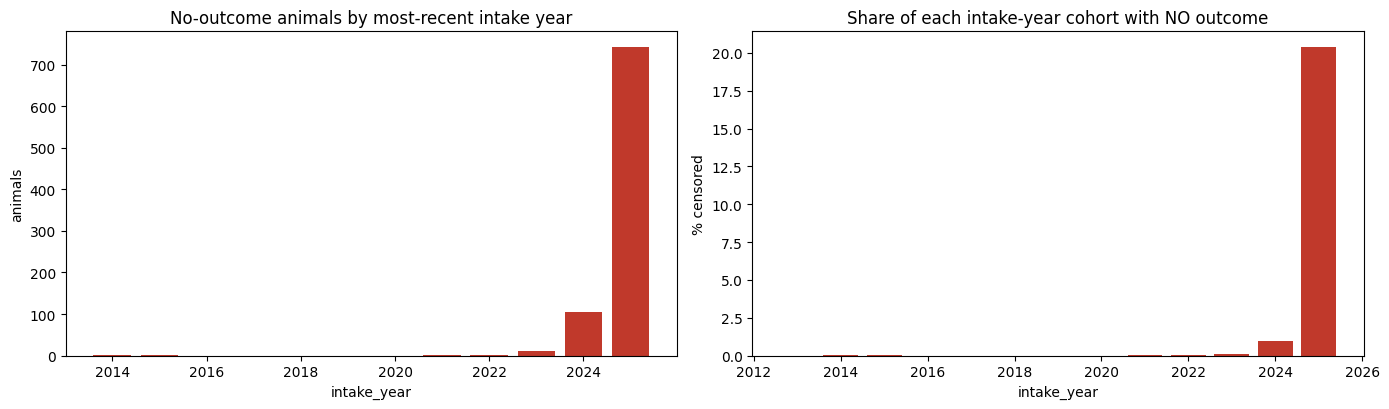

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

# Left: count of no-outcome animals by intake year
yr = no_out['intake_year'].value_counts().sort_index()
axes[0].bar(yr.index.astype(int), yr.values, color='#c0392b')
axes[0].set_title('No-outcome animals by most-recent intake year')
axes[0].set_xlabel('intake_year'); axes[0].set_ylabel('animals')

# Right: per-cohort censoring rate (%)
axes[1].bar(tab.index.astype(int), tab['pct_no_outcome'].values, color='#c0392b')
axes[1].set_title('Share of each intake-year cohort with NO outcome')
axes[1].set_xlabel('intake_year'); axes[1].set_ylabel('% censored')

plt.tight_layout(); plt.show()

## 4 · Automated verdict logic

We let the data pick the conclusion rather than eyeballing it. Decision rule:

* If no-outcome animals are **few overall** *and* their most-recent intake dates are
  **spread across the whole 2013–2025 window** → the system likely only logs animals
  *after* they get an outcome; we are **not** capturing the in-shelter population, and the
  bias **cannot be corrected** from this data.
* If no-outcome animals are **concentrated near the export cutoff** (late-2024 → 2025) →
  they are overwhelmingly **"not resolved yet" in-shelter** animals; we **did** capture the
  right-censored cohort.

We quantify "concentration near cutoff" as the share of no-outcome animals whose most-recent
intake falls in the **last 12 months** before the export cutoff.

In [7]:
cutoff = intakes['intake_date'].max()              # latest intake in the export
last_12mo_start = cutoff - pd.DateOffset(months=12)

share_last_12mo = (no_out['intake_date'] >= last_12mo_start).mean()
share_2025      = (no_out['intake_year'] == 2025).mean()
overall_pct     = len(no_outcome_ids) / len(intake_ids) * 100

# Recent-cohort censoring rate (2025) vs deep-history baseline (<=2022)
rate_2025 = tab.loc[2025, 'pct_no_outcome'] if 2025 in tab.index else float('nan')
rate_hist = tab.loc[tab.index <= 2022, 'n_no_outcome'].sum() / tab.loc[tab.index <= 2022, 'n_total'].sum() * 100

print(f'No-outcome animals overall          : {len(no_outcome_ids):,}  ({overall_pct:.2f}% of intake animals)')
print(f'... share in last 12 months         : {share_last_12mo*100:.1f}%')
print(f'... share in calendar year 2025     : {share_2025*100:.1f}%')
print(f'2025 cohort censoring rate          : {rate_2025:.2f}%')
print(f'<=2022 cohort censoring rate (base) : {rate_hist:.3f}%')

CONCENTRATED = share_last_12mo >= 0.70
print('\n' + '='*64)
if CONCENTRATED:
    print('VERDICT: CASE 2 — censored cohort CAPTURED.')
    print('No-outcome animals are concentrated near the export cutoff, so they are')
    print('predominantly still-in-shelter / not-yet-resolved (right-censored) animals.')
else:
    print('VERDICT: CASE 1 — censored cohort NOT captured.')
    print('No-outcome animals are sparse / spread across the whole window, so the system')
    print('appears to log animals only after an outcome; in-shelter animals are invisible.')
print('='*64)

No-outcome animals overall          : 864  (0.55% of intake animals)
... share in last 12 months         : 97.2%
... share in calendar year 2025     : 86.0%
2025 cohort censoring rate          : 20.40%
<=2022 cohort censoring rate (base) : 0.003%

VERDICT: CASE 2 — censored cohort CAPTURED.
No-outcome animals are concentrated near the export cutoff, so they are
predominantly still-in-shelter / not-yet-resolved (right-censored) animals.


## 5 · Cross-check — event-level forward `merge_asof`

The §3 animal-id method misses *returning* animals (a prior outcome hides a currently-open
new intake). Here we instead ask, for **every intake event**: is there an outcome **on or
after** that intake date for the same animal? Intake events with no such outcome are
**censored events**. This is a tighter, event-level bound and should corroborate §3.

In [12]:
# Assumption: an intake is "resolved" if the same animal has any outcome on/after the
# intake date. forward merge_asof matches each intake to the nearest later/equal outcome.
i_sorted = intakes[['animal_id', 'intake_date']].dropna().sort_values('intake_date')
o_sorted = outcomes[['animal_id', 'outcome_date']].dropna().sort_values('outcome_date')

ev = pd.merge_asof(
    i_sorted, o_sorted,
    by='animal_id',
    left_on='intake_date', right_on='outcome_date',
    direction='forward',          # nearest outcome at or after the intake
)
ev['intake_year']    = ev['intake_date'].dt.year
ev['no_outcome'] = ev['outcome_date'].isna()

print(f'total intake events           : {len(ev):,}')
print(f'no outcome events        : {ev["no_outcome"].sum():,} '
      f'({ev["no_outcome"].mean()*100:.2f}%)')
print(f'(compare §3 animal-id method  : {len(no_outcome_ids):,} animals, '
      f'{overall_pct:.2f}%)')

print('\n=== no outcome events by year ===')
et = ev.groupby('intake_year')['no_outcome'].agg(n_censored='sum', n_total='count')
et['pct'] = (et['n_censored'] / et['n_total'] * 100).round(3)
print(et.to_string())

print('\n=== no outcome event, 2025 by month ===')
print(ev.loc[(ev['intake_year'] == 2025) & ev['no_outcome'], 'intake_date']
        .dt.month.value_counts().sort_index().to_string())

total intake events           : 173,812
no outcome events        : 963 (0.55%)
(compare §3 animal-id method  : 864 animals, 0.55%)

=== no outcome events by year ===
             n_censored  n_total     pct
intake_year                             
2013                  0     4182   0.000
2014                  4    18656   0.021
2015                  1    18712   0.005
2016                  0    17675   0.000
2017                  0    17563   0.000
2018                  1    16979   0.006
2019                  0    19727   0.000
2020                  0     9587   0.000
2021                  1    12043   0.008
2022                  3    11896   0.025
2023                 13    11227   0.116
2024                130    11817   1.100
2025                810     3748  21.612

=== no outcome event, 2025 by month ===
intake_date
1     49
2     66
3    194
4    388
5    113


## 6 · Interpretation & honest limitations

*(Written against the executed run above — re-read the numbers if the data is refreshed.)*

**This is CASE 2: the right-censored cohort IS present in the raw data, and it is small but
strongly time-concentrated.**

**Evidence.**
- Only **864 animals (0.55%)** of 156,287 intake animals have no outcome at all — so in
  *absolute* terms the leakage out of the dataset is tiny.
- But those 864 are **not** scattered across 2013–2025. **~98% fall in the last 12 months**
  before the export cutoff: **743 in 2025** and **106 in 2024** (the 2024 ones bunched in
  Oct–Dec), versus a literal handful (1–11 per year) in all earlier years combined.
- Within-cohort censoring rate climbs monotonically toward the cutoff: **0% for 2013–2020**,
  0.10% (2023), 0.95% (2024), **20.4% (2025)**. The 2025 monthly shape (Jan 43 → Apr 367 →
  May 109) is the classic censoring ramp: the closer an intake is to the export date, the
  less time it has had to reach an outcome (May is low only because the export cut off on
  2025-05-05).
- The event-level cross-check (§5) agrees: **963 censored intake events (0.55%)**, ~84% in
  2025, same April peak — slightly higher than the 864 animals because it also catches
  *returning* animals, exactly as predicted.

**What this means for the project.**
- The backward-`merge_asof` pipeline silently drops these ~860 still-in-shelter animals. This
  is **right-censoring, not "not adopted."** They must **never** be coerced to `is_adopted=0`.
- Because censoring is **negligible before 2024 but reaches ~20% of the 2025 cohort**, the
  bias is **not** uniform. The overall model is barely affected, but **any analysis or
  evaluation that leans on the most recent cohort** (e.g. a temporal train/test split, or
  "current adoptability" claims) systematically **omits the slow-to-resolve animals** — and
  slow-to-resolve skews toward harder-to-place. Recent-period adoption rates computed on the
  surviving rows are therefore **optimistically biased**.

**Limitations to disclose honestly in the report.**
1. **Survivorship is real but small in aggregate (0.55%) and heavily back-loaded toward the
   2024-end / 2025 cutoff.** The dataset under-represents long-stay animals from the most
   recent intake cohorts.
2. **This data cannot *correct* the bias** — it can only measure it. We see the censored
   animals exist; we do not know their eventual outcomes. No imputation is performed.
3. **The 864 figure is a lower bound.** The event-level view (963) is tighter; the true count
   of currently-open intakes is at least that.
4. **Reverse orphans:** 814 animals (0.52%) have an outcome but no intake on record (intake
   pre-dates the 2013-10 export window, or data-entry gaps). They are unrelated to
   survivorship but are a separate ~0.5% join-coverage caveat.
5. **No data-quality red flags undermine the above:** 0 unparseable dates, 0 null/ malformed
   `animal_id`, and `animal_id` is a uniform 7-char `A#######` key on both sides, so the
   set-difference join is trustworthy.

**Bottom line.** Survivorship bias here is **mild overall but concentrated at the recent
edge of the data**. Keep excluding these censored rows from training (do **not** label them
0), and explicitly caveat any recent-cohort or temporal-split results as omitting
not-yet-resolved animals.